# Project VGG

## Download and Store the Open Images

We download images from the ["Apple", "Banana", "Lemon"] classes.

In [1]:
#!pip install fiftyone datasets torch torchvision

In [2]:
import fiftyone as fo
import pandas as pd
from fiftyone import ViewField as F
from pathlib import Path


/home/cahya/miniconda3/envs/cv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
my_classes = ["Apple", "Banana", "Lemon"]
export_dir = "./project-vgg"


In [4]:
if not Path(export_dir).exists():
    Path(export_dir).mkdir(parents=True, exist_ok=True)
    dataset = fo.zoo.load_zoo_dataset(
        "open-images-v7",
        split="train",
        label_types=["detections"],
        classes=my_classes,
        max_samples=100,
        shuffle=True
    )

    dataset = dataset.filter_labels("ground_truth", F("label").is_in(my_classes))

    patches = dataset.to_patches("ground_truth")

    patches.export(
        export_dir=export_dir,
        dataset_type=fo.types.ImageClassificationDirectoryTree,
        label_field="ground_truth",
    )

## Load the images as Huggingface dataset

In [5]:
from datasets import load_dataset

**Set random seed for reproducibility**

In [6]:
import os
import random
import numpy as np
import torch

seed = 42

def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(seed)
print(f"Random seed set to {seed}")

Random seed set to 42


In [7]:
# Load images where each subfolder is treated as a class label
hf_dataset = load_dataset("imagefolder", data_dir=export_dir)

# Class names inferred from subdirectory names
class_names = hf_dataset["train"].features["label"].names
print("Classes:", class_names)

hf_dataset

Classes: ['Apple', 'Banana', 'Lemon']


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 256
    })
})

## Analyse the Dataset

**Explore the dataset**
- What classes? 
- Distribution of images? 
- Any imbalances? 
- What did you notice about the images that could affect the model training and performance?

In [8]:
# Explore class distribution
train_ds = hf_dataset["train"]
n_images = len(train_ds)

label_counts = pd.Series(train_ds["label"]).value_counts().sort_index()
dist_df = pd.DataFrame(
    {
        "class_id": label_counts.index,
        "class_name": [class_names[i] for i in label_counts.index],
        "images": label_counts.values,
    }
).sort_values("images", ascending=False).reset_index(drop=True)

dist_df["share_%"] = (dist_df["images"] / n_images * 100).round(2)

print(f"Total images: {n_images}")
print("\nClass distribution:")
display(dist_df)

if dist_df["images"].min() > 0:
    imbalance_ratio = dist_df["images"].max() / dist_df["images"].min()
    print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")
else:
    print("\nAt least one class has 0 images.")

# Explore image properties that may affect training
img_rows = []
for sample in train_ds:
    img = sample["image"]   # PIL image
    w, h = img.size
    img_rows.append(
        {
            "label_id": sample["label"],
            "class_name": class_names[sample["label"]],
            "width": w,
            "height": h,
            "aspect_ratio": w / h if h else None,
            "mode": img.mode,
            "min_side": min(w, h),
        }
    )

img_df = pd.DataFrame(img_rows)

print("\nImage size summary:")
display(img_df[["width", "height", "aspect_ratio"]].describe().round(2))

print("\nColor mode distribution:")
display(img_df["mode"].value_counts().rename_axis("mode").reset_index(name="count"))

print("\nTop 10 most common resolutions:")
display(
    img_df.groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(10)
)

small_share = (img_df["min_side"] < 128).mean() * 100
extreme_ar_share = ((img_df["aspect_ratio"] > 2.0) | (img_df["aspect_ratio"] < 0.5)).mean() * 100

print("\nPotential training-impact observations:")
print(f"- Very small images (min side < 128 px): {small_share:.2f}%")
print(f"- Extreme aspect ratios (<0.5 or >2.0): {extreme_ar_share:.2f}%")

if imbalance_ratio > 1.5:
    print("- Noticeable class imbalance: might need class weighting, resampling, or augmentation.")
else:
    print("- Class balance looks fairly reasonable.")

if img_df["mode"].nunique() > 1:
    print("- Mixed image modes detected (e.g., RGB/RGBA/L): standardize preprocessing to a single mode (usually RGB).")

if small_share > 20:
    print("- Many small images may reduce feature quality; careful resizing/augmentation is important.")

if extreme_ar_share > 15:
    print("- Many extreme aspect ratios: use robust resize/crop strategy to avoid distortion.")

Total images: 256

Class distribution:


,class_id,class_name,images,share_%
0,0,Apple,153,59.77
1,2,Lemon,52,20.31
2,1,Banana,51,19.92



Imbalance ratio (max/min): 3.00

Image size summary:


,width,height,aspect_ratio
count,256.00,256.00,256.00
mean,272.25,248.23,1.25
std,228.16,194.37,0.75
min,15.00,5.00,0.21
25%,133.75,115.00,0.88
50%,202.50,193.50,1.10
75%,331.75,335.25,1.36
max,1023.00,944.00,5.79



Color mode distribution:


,mode,count
0,RGB,256



Top 10 most common resolutions:


,width,height,count
0,15,5,1
1,15,49,1
2,17,37,1
3,20,30,1
4,21,22,1
5,21,24,1
6,21,48,1
7,26,55,1
8,27,35,1
9,29,32,1



Potential training-impact observations:
- Very small images (min side < 128 px): 33.20%
- Extreme aspect ratios (<0.5 or >2.0): 16.02%
- Noticeable class imbalance: might need class weighting, resampling, or augmentation.
- Many small images may reduce feature quality; careful resizing/augmentation is important.
- Many extreme aspect ratios: use robust resize/crop strategy to avoid distortion.


## Split the Dataset

Preparation: Split dataset into a 75/25 Train/test split

In [9]:
# 75/25 train-test split (stratified by class label)
hf_dataset = hf_dataset["train"].train_test_split(
    test_size=0.25,
    seed=42,
    stratify_by_column="label",
)

train_ds = hf_dataset["train"]
test_ds = hf_dataset["test"]

print(f"Train samples: {len(train_ds)} ({len(train_ds)/n_images:.2%})")
print(f"Test samples:  {len(test_ds)} ({len(test_ds)/n_images:.2%})")

Train samples: 192 (75.00%)
Test samples:  64 (25.00%)


## Train VGG16 from scratch

Train a VGG 16 network from scratch (randomly initialized weights) and estimate the testset accuracy.

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import torch.nn as nn

In [11]:
# The architecture configuration for VGG16
# Improved VGG initialization: He/Kaiming for conv layers, Xavier for linear layers
# Numbers represent the number of output channels in a Conv2d layer
# 'M' represents a MaxPool2d layer
VGG16_CONFIG = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']

class VGG16(nn.Module):
    def __init__(self, weights=None, in_channels=3, num_classes=1000):
        super().__init__()
        self.in_channels = in_channels

        self.features = self.create_conv_layers(VGG16_CONFIG)
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, num_classes),
        )

        if weights is None:
            self._initialize_weights()
        else:
            self.load_state_dict(weights)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels

        for x in architecture:
            if isinstance(x, int):
                layers.extend([
                    nn.Conv2d(in_channels, x, kernel_size=3, stride=1, padding=1),
                    nn.ReLU(inplace=True),
                ])
                in_channels = x
            elif x == "M":
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)


In [12]:
%%time

# Reuse existing train_ds, test_ds, class_names from previous cells
num_classes = len(class_names)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class HFDatasetWrapper(Dataset):
    def __init__(self, hf_split, transform=None):
        self.ds = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        image = sample["image"].convert("RGB")
        label = sample["label"]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

train_torch_ds = HFDatasetWrapper(train_ds, transform=train_tfms)
test_torch_ds = HFDatasetWrapper(test_ds, transform=test_tfms)

train_loader = DataLoader(train_torch_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_torch_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# VGG16 from scratch (randomly initialized)
# model = models.vgg16(weights=None)
model = VGG16(weights=None)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f}")

# Test accuracy
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Estimated test accuracy: {test_acc:.4f} ({100*test_acc:.2f}%)")

/home/cahya/miniconda3/envs/cv/lib/python3.13/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/10 | train_loss=1.0119 | train_acc=0.5677
Epoch 2/10 | train_loss=0.8382 | train_acc=0.5990
Epoch 3/10 | train_loss=0.7336 | train_acc=0.5990
Epoch 4/10 | train_loss=0.7014 | train_acc=0.5990
Epoch 5/10 | train_loss=0.6974 | train_acc=0.5781
Epoch 6/10 | train_loss=0.7270 | train_acc=0.6198
Epoch 7/10 | train_loss=0.6765 | train_acc=0.6406
Epoch 8/10 | train_loss=0.7315 | train_acc=0.6562
Epoch 9/10 | train_loss=0.6933 | train_acc=0.6562
Epoch 10/10 | train_loss=0.6293 | train_acc=0.7135
Estimated test accuracy: 0.6875 (68.75%)
CPU times: user 11.3 s, sys: 1.1 s, total: 12.4 s
Wall time: 12.5 s


## Transfer Learning

Experiment transfer learning: Use an imagenet pretrained VGG 16 architecture, train the model and estimate the testset accuracy. Show the differences in loss and accuracy of the plain and pre-trained network over the first 10 epochs.

Final test accuracy (plain):      0.5938
Final test accuracy (pretrained): 1.0000


,epoch,train_loss_plain,train_acc_plain,test_loss_plain,test_acc_plain,train_loss_pretrained,train_acc_pretrained,test_loss_pretrained,test_acc_pretrained,delta_train_loss_pre_minus_plain,delta_test_loss_pre_minus_plain,delta_train_acc_pre_minus_plain,delta_test_acc_pre_minus_plain
0,1,0.9660,0.5677,0.8037,0.5938,0.9943,0.5469,0.7314,0.7188,0.0283,-0.0724,-0.0208,0.1250
1,2,0.7660,0.5990,0.7138,0.5938,0.6944,0.6979,0.5737,0.7500,-0.0716,-0.1401,0.0990,0.1562
2,3,0.7119,0.5990,0.7431,0.5938,0.5658,0.7396,0.4482,0.8594,-0.1461,-0.2950,0.1406,0.2656
3,4,0.7168,0.6198,0.7328,0.7188,0.3941,0.8698,0.3152,0.9219,-0.3227,-0.4176,0.2500,0.2031
4,5,0.6815,0.6458,0.7100,0.6250,0.2452,0.9167,0.1906,0.9688,-0.4362,-0.5194,0.2708,0.3438
5,6,0.6716,0.5990,0.6952,0.6250,0.1519,0.9479,0.1554,1.0000,-0.5197,-0.5398,0.3490,0.3750
6,7,0.6504,0.6510,0.6991,0.5625,0.1001,0.9792,0.0810,1.0000,-0.5503,-0.6181,0.3281,0.4375
7,8,0.6669,0.6406,0.6742,0.6719,0.0679,0.9740,0.0641,1.0000,-0.5989,-0.6102,0.3333,0.3281
8,9,0.6956,0.6458,0.7300,0.6250,0.0521,0.9896,0.0505,1.0000,-0.6436,-0.6796,0.3438,0.3750
9,10,0.6935,0.6042,0.7296,0.5938,0.0345,0.9948,0.0434,1.0000,-0.6590,-0.6862,0.3906,0.4062


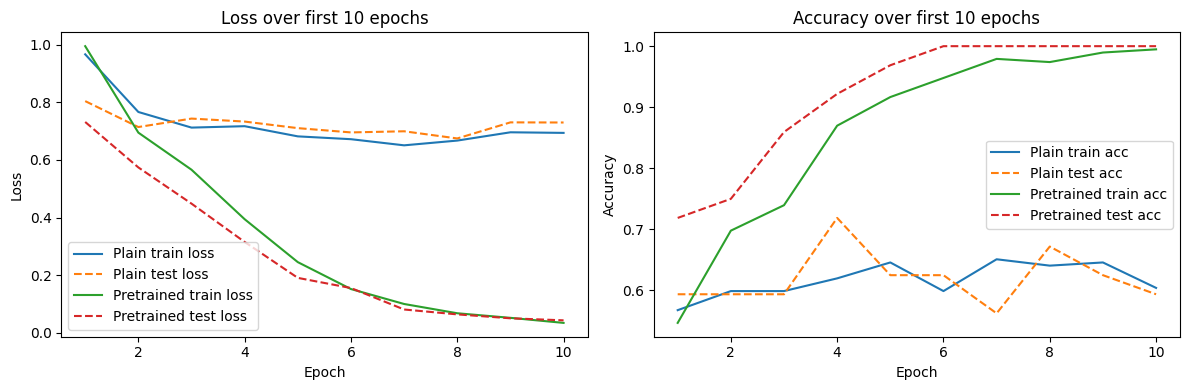

CPU times: user 24.3 s, sys: 2.4 s, total: 26.7 s
Wall time: 28.2 s


In [13]:
%%time

# Compare plain VGG16 (random init) vs ImageNet-pretrained VGG16 over 10 epochs

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct_preds, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = loss_fn(out, y)

            total_loss += loss.item() * x.size(0)
            pred = out.argmax(dim=1)
            correct_preds += (pred == y).sum().item()
            total_samples += y.size(0)

    return total_loss / total_samples, correct_preds / total_samples

def train_and_track(model, train_loader, test_loader, loss_fn, device, epochs=10, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for ep in range(1, epochs + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            pred = out.argmax(dim=1)
            running_correct += (pred == y).sum().item()
            running_total += y.size(0)

        train_loss_ep = running_loss / running_total
        train_acc_ep = running_correct / running_total
        test_loss_ep, test_acc_ep = evaluate(model, test_loader, loss_fn, device)

        history.append(
            {
                "epoch": ep,
                "train_loss": train_loss_ep,
                "train_acc": train_acc_ep,
                "test_loss": test_loss_ep,
                "test_acc": test_acc_ep,
            }
        )

    return pd.DataFrame(history)

# 1) Plain VGG16 (from scratch)
# plain_model = models.vgg16(weights=None)
plain_model = models.vgg16(weights=None)
plain_model.classifier[6] = nn.Linear(plain_model.classifier[6].in_features, num_classes)
plain_model = plain_model.to(device)

plain_hist = train_and_track(
    model=plain_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=criterion,
    device=device,
    epochs=10,
    lr=1e-4,
)

# 2) Pretrained VGG16 (ImageNet)
pretrained_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
pretrained_model.classifier[6] = nn.Linear(pretrained_model.classifier[6].in_features, num_classes)
pretrained_model = pretrained_model.to(device)

pre_hist = train_and_track(
    model=pretrained_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=criterion,
    device=device,
    epochs=10,
    lr=1e-5,  # smaller LR is usually better for fine-tuning
)

# Build comparison table
comparison = plain_hist.merge(pre_hist, on="epoch", suffixes=("_plain", "_pretrained"))
comparison["delta_train_loss_pre_minus_plain"] = comparison["train_loss_pretrained"] - comparison["train_loss_plain"]
comparison["delta_test_loss_pre_minus_plain"] = comparison["test_loss_pretrained"] - comparison["test_loss_plain"]
comparison["delta_train_acc_pre_minus_plain"] = comparison["train_acc_pretrained"] - comparison["train_acc_plain"]
comparison["delta_test_acc_pre_minus_plain"] = comparison["test_acc_pretrained"] - comparison["test_acc_plain"]

print("Final test accuracy (plain):      {:.4f}".format(plain_hist.iloc[-1]["test_acc"]))
print("Final test accuracy (pretrained): {:.4f}".format(pre_hist.iloc[-1]["test_acc"]))
display(comparison.round(4))

# Optional quick plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(comparison["epoch"], comparison["train_loss_plain"], label="Plain train loss")
axes[0].plot(comparison["epoch"], comparison["test_loss_plain"], "--", label="Plain test loss")
axes[0].plot(comparison["epoch"], comparison["train_loss_pretrained"], label="Pretrained train loss")
axes[0].plot(comparison["epoch"], comparison["test_loss_pretrained"], "--", label="Pretrained test loss")
axes[0].set_title("Loss over first 10 epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(comparison["epoch"], comparison["train_acc_plain"], label="Plain train acc")
axes[1].plot(comparison["epoch"], comparison["test_acc_plain"], "--", label="Plain test acc")
axes[1].plot(comparison["epoch"], comparison["train_acc_pretrained"], label="Pretrained train acc")
axes[1].plot(comparison["epoch"], comparison["test_acc_pretrained"], "--", label="Pretrained test acc")
axes[1].set_title("Accuracy over first 10 epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Data Augmentation

Experiment data augmentation: Add data augmentation and train again, discuss results
- Random rotate
- Random translate
- Random crop

### Train the plain VGG with data augmentation

In [14]:
%%time

# Augmentation experiment (from scratch): random crop + random rotate + random translate
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

train_aug_scratch_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),       # random crop
    transforms.RandomRotation(degrees=20),                      # random rotate
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)), # random translate
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_aug_scratch_ds = HFDatasetWrapper(train_ds, transform=train_aug_scratch_tfms)
train_aug_scratch_loader = DataLoader(
    train_aug_scratch_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True
)

# Train VGG16 from scratch again (same setup as plain model)
# aug_scratch_model = models.vgg16(weights=None)
aug_scratch_model = VGG16(weights=None)
aug_scratch_model.classifier[6] = nn.Linear(aug_scratch_model.classifier[6].in_features, num_classes)
aug_scratch_model = aug_scratch_model.to(device)

aug_scratch_hist = train_and_track(
    model=aug_scratch_model,
    train_loader=train_aug_scratch_loader,
    test_loader=test_loader,
    loss_fn=criterion,
    device=device,
    epochs=10,
    lr=1e-4,
)

# Compare against previous scratch baseline (plain_hist)
scratch_aug_comparison = plain_hist.merge(aug_scratch_hist, on="epoch", suffixes=("_plain", "_aug"))
scratch_aug_comparison["delta_test_acc_aug_minus_plain"] = (
    scratch_aug_comparison["test_acc_aug"] - scratch_aug_comparison["test_acc_plain"]
)
scratch_aug_comparison["delta_test_loss_aug_minus_plain"] = (
    scratch_aug_comparison["test_loss_aug"] - scratch_aug_comparison["test_loss_plain"]
)

display(scratch_aug_comparison.round(4))

plain_final = plain_hist.iloc[-1]["test_acc"]
aug_final = aug_scratch_hist.iloc[-1]["test_acc"]
plain_best = plain_hist["test_acc"].max()
aug_best = aug_scratch_hist["test_acc"].max()

print(f"Final test acc (plain scratch): {plain_final:.4f}")
print(f"Final test acc (aug scratch):   {aug_final:.4f}")
print(f"Best  test acc (plain scratch): {plain_best:.4f}")
print(f"Best  test acc (aug scratch):   {aug_best:.4f}")

if aug_best > plain_best:
    print("Discussion: augmentation improved generalization for scratch training.")
elif aug_best < plain_best:
    print("Discussion: augmentation appears too strong or dataset too small; scratch performance dropped.")
else:
    print("Discussion: augmentation had limited impact on peak scratch test accuracy.")

/home/cahya/miniconda3/envs/cv/lib/python3.13/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


,epoch,train_loss_plain,train_acc_plain,test_loss_plain,test_acc_plain,train_loss_aug,train_acc_aug,test_loss_aug,test_acc_aug,delta_test_acc_aug_minus_plain,delta_test_loss_aug_minus_plain
0,1,0.9660,0.5677,0.8037,0.5938,1.0428,0.5677,0.9936,0.5938,0.0000,0.1898
1,2,0.7660,0.5990,0.7138,0.5938,0.8932,0.5990,0.7827,0.5938,0.0000,0.0689
2,3,0.7119,0.5990,0.7431,0.5938,0.7764,0.5990,0.7912,0.5938,0.0000,0.0480
3,4,0.7168,0.6198,0.7328,0.7188,0.7515,0.5990,0.7012,0.5938,-0.1250,-0.0316
4,5,0.6815,0.6458,0.7100,0.6250,0.6987,0.5990,0.6803,0.5938,-0.0312,-0.0297
5,6,0.6716,0.5990,0.6952,0.6250,0.7021,0.6042,0.6862,0.5938,-0.0312,-0.0090
6,7,0.6504,0.6510,0.6991,0.5625,0.7009,0.6406,0.7008,0.6562,0.0938,0.0017
7,8,0.6669,0.6406,0.6742,0.6719,0.6940,0.6615,0.6507,0.6719,0.0000,-0.0235
8,9,0.6956,0.6458,0.7300,0.6250,0.6669,0.6615,0.6780,0.6719,0.0469,-0.0520
9,10,0.6935,0.6042,0.7296,0.5938,0.6713,0.6406,0.6987,0.7188,0.1250,-0.0309


Final test acc (plain scratch): 0.5938
Final test acc (aug scratch):   0.7188
Best  test acc (plain scratch): 0.7188
Best  test acc (aug scratch):   0.7188
Discussion: augmentation had limited impact on peak scratch test accuracy.
CPU times: user 12.1 s, sys: 1.13 s, total: 13.2 s
Wall time: 14.1 s


If we train it longer, we can get better result with data augmentation. 
Following is the result for 50 epochs:
```
Final test acc (plain scratch): 0.5938
Final test acc (aug scratch):   0.7344
Best  test acc (plain scratch): 0.7188
Best  test acc (aug scratch):   0.7656
Discussion: augmentation improved generalization for scratch training.
CPU times: user 54.9 s, sys: 5.32 s, total: 1min
Wall time: 1min 7s
```

### Train the pre-trained VGG with data augmentation

In [15]:
%%time

# Stronger augmentation: random rotate + random translate + random crop
train_aug_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),      # random crop
    transforms.RandomRotation(degrees=20),                     # random rotate
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)),# random translate
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_aug_torch_ds = HFDatasetWrapper(train_ds, transform=train_aug_tfms)
train_aug_loader = DataLoader(train_aug_torch_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# Train again (pretrained backbone, same setup as previous experiment)
aug_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
aug_model.classifier[6] = nn.Linear(aug_model.classifier[6].in_features, num_classes)
aug_model = aug_model.to(device)

aug_hist = train_and_track(
    model=aug_model,
    train_loader=train_aug_loader,
    test_loader=test_loader,
    loss_fn=criterion,
    device=device,
    epochs=10,
    lr=1e-5,
)

# Compare against previous pretrained run (pre_hist)
aug_comparison = pre_hist.merge(aug_hist, on="epoch", suffixes=("_base", "_aug"))
aug_comparison["delta_test_acc_aug_minus_base"] = aug_comparison["test_acc_aug"] - aug_comparison["test_acc_base"]
aug_comparison["delta_test_loss_aug_minus_base"] = aug_comparison["test_loss_aug"] - aug_comparison["test_loss_base"]

display(aug_comparison.round(4))

base_final = pre_hist.iloc[-1]["test_acc"]
aug_final = aug_hist.iloc[-1]["test_acc"]
base_best = pre_hist["test_acc"].max()
aug_best = aug_hist["test_acc"].max()

print(f"Final test acc (baseline pretrained): {base_final:.4f}")
print(f"Final test acc (augmented pretrained): {aug_final:.4f}")
print(f"Best  test acc (baseline pretrained): {base_best:.4f}")
print(f"Best  test acc (augmented pretrained): {aug_best:.4f}")

if aug_best > base_best:
    print("Discussion: augmentation improved generalization (higher best test accuracy).")
elif aug_best < base_best:
    print("Discussion: augmentation was too strong for this small dataset; test accuracy dropped.")
else:
    print("Discussion: augmentation had little effect on peak test accuracy.")

/home/cahya/miniconda3/envs/cv/lib/python3.13/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


,epoch,train_loss_base,train_acc_base,test_loss_base,test_acc_base,train_loss_aug,train_acc_aug,test_loss_aug,test_acc_aug,delta_test_acc_aug_minus_base,delta_test_loss_aug_minus_base
0,1,0.9943,0.5469,0.7314,0.7188,1.0142,0.5312,0.8031,0.7188,0.0000,0.0718
1,2,0.6944,0.6979,0.5737,0.7500,0.7717,0.6302,0.6499,0.7969,0.0469,0.0762
2,3,0.5658,0.7396,0.4482,0.8594,0.6707,0.6875,0.5138,0.8750,0.0156,0.0656
3,4,0.3941,0.8698,0.3152,0.9219,0.5086,0.8125,0.4068,0.9219,0.0000,0.0916
4,5,0.2452,0.9167,0.1906,0.9688,0.3448,0.8750,0.2650,0.9375,-0.0312,0.0743
5,6,0.1519,0.9479,0.1554,1.0000,0.2505,0.9271,0.1975,0.9688,-0.0312,0.0421
6,7,0.1001,0.9792,0.0810,1.0000,0.1532,0.9688,0.1206,1.0000,0.0000,0.0396
7,8,0.0679,0.9740,0.0641,1.0000,0.1510,0.9531,0.0990,1.0000,0.0000,0.0349
8,9,0.0521,0.9896,0.0505,1.0000,0.1143,0.9635,0.0826,1.0000,0.0000,0.0322
9,10,0.0345,0.9948,0.0434,1.0000,0.0573,0.9896,0.0823,1.0000,0.0000,0.0389


Final test acc (baseline pretrained): 1.0000
Final test acc (augmented pretrained): 1.0000
Best  test acc (baseline pretrained): 1.0000
Best  test acc (augmented pretrained): 1.0000
Discussion: augmentation had little effect on peak test accuracy.
CPU times: user 11.9 s, sys: 1.27 s, total: 13.2 s
Wall time: 13.9 s


## Rebuild VGG19

Experiment with architecture: Rebuild VGG19. After layer block4_conv4 (32, 32, 512):

In [16]:
%%time

# VGG19 experiment: cut at block4_conv4 (features[25]) and add a custom head
class VGG19_Block4Conv4_Head(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        weights = models.VGG19_Weights.IMAGENET1K_V1 if pretrained else None
        base = models.vgg19(weights=weights)

        # Up to and including block4_conv4
        self.features = nn.Sequential(*list(base.features.children())[:26])

        # New layers after block4_conv4
        self.head = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


vgg19_b4_model = VGG19_Block4Conv4_Head(num_classes=num_classes, pretrained=True).to(device)

vgg19_b4_hist = train_and_track(
    model=vgg19_b4_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=criterion,
    device=device,
    epochs=10,
    lr=1e-5,
)

print(f"VGG19(block4_conv4 head) final test acc: {vgg19_b4_hist.iloc[-1]['test_acc']:.4f}")
print(f"VGG16 pretrained final test acc:         {pre_hist.iloc[-1]['test_acc']:.4f}")

vgg_compare = pre_hist[["epoch", "test_acc", "test_loss"]].merge(
    vgg19_b4_hist[["epoch", "test_acc", "test_loss"]],
    on="epoch",
    suffixes=("_vgg16_pre", "_vgg19_b4"),
)
display(vgg_compare.round(4))

VGG19(block4_conv4 head) final test acc: 0.9219
VGG16 pretrained final test acc:         1.0000


,epoch,test_acc_vgg16_pre,test_loss_vgg16_pre,test_acc_vgg19_b4,test_loss_vgg19_b4
0,1,0.7188,0.7314,0.6719,0.8266
1,2,0.7500,0.5737,0.7656,0.6047
2,3,0.8594,0.4482,0.8750,0.4342
3,4,0.9219,0.3152,0.9375,0.2992
4,5,0.9688,0.1906,0.9375,0.2287
5,6,1.0000,0.1554,0.9531,0.2289
6,7,1.0000,0.0810,0.9375,0.1910
7,8,1.0000,0.0641,0.9062,0.1907
8,9,1.0000,0.0505,0.9531,0.1489
9,10,1.0000,0.0434,0.9219,0.1640


CPU times: user 11.5 s, sys: 1.36 s, total: 12.9 s
Wall time: 13.4 s
